# Integración de las tres capas

Cruce de la **Capa 1** (contexto y necesidades), la **Capa 2** (intereses, hábitos y aspiraciones) y la
**Capa 3** (oferta y convocatoria) para identificar patrones, brechas y propuestas de actividades con
trazabilidad. La lectura principal está en `resultados/informe_final.md`; la metodología, en
`fuentes/metodologia_integracion.md`.

**Reglas del cruce**
- La **ausencia de oferta no es demanda** y la **frecuencia de oferta no es interés**.
- Las **señales de demanda** se refieren solo a la oferta concreta en que se observaron (una beca, unos talleres).
- Los resultados de actividades para **niños y adolescentes** no se generalizan a la juventud.
- Los niveles geográficos no se mezclan: Lima Metropolitana ≠ Lima Este ≠ distrito.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

pd.set_option("display.max_colwidth", 120); pd.set_option("display.width", 220); pd.set_option("display.max_rows", 200)
RAIZ = Path("..")
AZUL, TINTA, TINTA_2, GRILLA, EJE, FONDO = "#2a78d6", "#0b0b0b", "#52514e", "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": FONDO, "axes.facecolor": FONDO, "axes.edgecolor": EJE, "axes.labelcolor": TINTA_2,
    "axes.titlecolor": TINTA, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "xtick.color": TINTA_2, "ytick.color": TINTA_2, "font.size": 9.5, "figure.dpi": 110,
})
DISTRITOS = ["Ate", "Chaclacayo", "El Agustino", "La Molina", "Lurigancho-Chosica", "San Juan de Lurigancho", "Santa Anita"]

R = RAIZ / "resultados"
hall = pd.read_csv(R / "hallazgos_integrados.csv")
pat = pd.read_csv(R / "patrones.csv")
prop = pd.read_csv(R / "propuestas.csv").fillna({"hallazgos_c2": ""})
reg = pd.read_csv(RAIZ / "fuentes" / "capa3_registro_oferta.csv", dtype={"ubigeo": str})
print(f"{len(hall)} hallazgos (capa 1: {sum(hall.capa == 1)}, capa 2: {sum(hall.capa == 2)}, capa 3: {sum(hall.capa == 3)}); "
      f"{len(pat)} patrones; {len(prop)} propuestas; {len(reg)} actividades en el registro de la Capa 3")

49 hallazgos (capa 1: 14, capa 2: 15, capa 3: 20); 12 patrones; 11 propuestas; 151 actividades en el registro de la Capa 3


## 1. Verificación de la trazabilidad

Todas las referencias deben existir: los hallazgos citados por patrones y propuestas, y las actividades del
registro (`C3-###`) citadas por los hallazgos. Cada propuesta cita hallazgos de la capa que corresponde a cada
columna.

In [2]:
ids = set(hall.id)
def citas(serie):
    return {x.strip() for v in serie.dropna() for x in str(v).split(";") if x.strip()}

faltan_pat = citas(pat.hallazgos) - ids
cols = ["hallazgos_c1", "hallazgos_c2", "hallazgos_c3"]
faltan_prop = set().union(*[citas(prop[c]) for c in cols]) - ids
capa_mal = [(p.id, c, h) for p in prop.itertuples() for c in cols for h in citas(pd.Series([getattr(p, c)]))
            if not h.startswith(f"H{c[-1]}-")]
c3_citados = {m for ref in hall.referencia for m in re.findall(r"C3-\d{3}", ref)}
faltan_c3 = c3_citados - set(reg.id)
assert not (faltan_pat or faltan_prop or capa_mal or faltan_c3), (faltan_pat, faltan_prop, capa_mal, faltan_c3)
usados = citas(pat.hallazgos) | set().union(*[citas(prop[c]) for c in cols])
print("Referencias verificadas: todas existen.")
print(f"Actividades del registro citadas por los hallazgos: {len(c3_citados)} de {len(reg)}")
print("Hallazgos no usados en patrones ni propuestas:", sorted(ids - usados) or "ninguno")
print("Propuestas sin hallazgos de alguna capa:")
display(prop.loc[(prop[cols] == "").any(axis=1), ["id", "propuesta"] + cols])

Referencias verificadas: todas existen.
Actividades del registro citadas por los hallazgos: 60 de 151
Hallazgos no usados en patrones ni propuestas: ninguno
Propuestas sin hallazgos de alguna capa:


,id,propuesta,hallazgos_c1,hallazgos_c2,hallazgos_c3
10,P11,"Componente de educación sexual integral y prevención de violencia para adolescentes, dentro de otras actividades",H1-13; H1-14,,H3-14


La propuesta P11 (componente de educación sexual integral y prevención) no tiene hallazgos de la Capa 2: ninguna
encuesta mide el interés de los adolescentes en esos temas. Por eso su nivel de interés es "sin evidencia" y se
plantea como componente dentro de otras actividades, no como actividad independiente.

## 2. Contexto por distrito

Reúne los datos distritales de la Capa 1 y la cobertura de la Capa 3. **No es un ranking de prioridad ni de
interés**: las tasas de los registros dependen del acceso a los servicios, y las actividades registradas dependen
de cuánto publica cada municipalidad.

In [3]:
P = RAIZ / "data" / "processed"
pob = pd.read_csv(P / "capa1_poblacion_resumen.csv")
pob = pob[(pob.anio == 2026) & (pob.lima_este == True)].set_index("distrito")
renoj = pd.read_csv(P / "capa1_renoj_resumen_distritos.csv").set_index("distrito")
vol = pd.read_csv(P / "capa1_voluntariado_resumen_distritos.csv").set_index("distrito")
regs = pd.read_csv(P / "capa1_registros_resumen.csv")
tasa = lambda r: regs[regs.registro == r].set_index("distrito").tasa
mediana = lambda r: regs[regs.registro == r].mediana_lima_metropolitana.iloc[0]
listado = pd.read_csv(RAIZ / "data" / "raw" / "capa3" / "gobpe_listado.csv")
por_d = reg.assign(distrito=reg.distrito.str.split("; ")).explode("distrito").reset_index(drop=True)

ctx = pd.DataFrame({
    "jóvenes 15–29 (2026)": pob.joven_15_29,
    "15–19 años": pob.joven_15_19,
    "% de los jóvenes de Lima Este": (100 * pob.joven_15_29 / pob.joven_15_29.sum()).round(1),
    "org. juveniles por 10 mil": renoj.organizaciones_por_10mil_jovenes.round(1),
    "voluntarios inscritos por 10 mil": vol.inscritas_por_10mil_jovenes.round(1),
    "maternidad adolescente (por 1 000 de 15–19)": tasa("maternidad_adolescente").round(1),
    "casos atendidos en los CEM (por 10 mil)": tasa("violencia_atendida_cem").round(1),
    "notas en gob.pe 2024–2026": listado.groupby("distrito").size(),
    "actividades registradas": por_d.groupby("distrito").size(),
    "dirigidas a jóvenes": por_d[por_d.incluye_15_29 == "juventud"].groupby("distrito").size(),
}).reindex(DISTRITOS)
ctx.loc["Lima Este"] = [pob.joven_15_29.sum(), pob.joven_15_19.sum(), 100.0, None, None, None, None,
                        len(listado), len(reg), int((reg.incluye_15_29 == "juventud").sum())]
ctx.loc["Mediana Lima Metropolitana"] = [None, None, None,
    renoj[renoj.nivel_geografico == "distrito"].organizaciones_por_10mil_jovenes.median().round(1),
    vol[vol.nivel_geografico == "distrito"].inscritas_por_10mil_jovenes.median().round(1),
    round(mediana("maternidad_adolescente"), 1), round(mediana("violencia_atendida_cem"), 1), None, None, None]
enteros = [c for c in ctx.columns if not c.startswith(("%", "org.", "voluntarios", "maternidad", "casos"))]
ctx.loc[DISTRITOS, "dirigidas a jóvenes"] = ctx.loc[DISTRITOS, "dirigidas a jóvenes"].fillna(0)
ctx[enteros] = ctx[enteros].astype("Int64")
display(ctx)

,jóvenes 15–29 (2026),15–19 años,% de los jóvenes de Lima Este,org. juveniles por 10 mil,voluntarios inscritos por 10 mil,maternidad adolescente (por 1 000 de 15–19),casos atendidos en los CEM (por 10 mil),notas en gob.pe 2024–2026,actividades registradas,dirigidas a jóvenes
distrito,,,,,,,,,,
Ate,176748,55842,24.8,1.7,27.1,17.1,51.1,150,26,6
Chaclacayo,9141,2988,1.3,3.3,38.3,13.3,67.3,6,3,0
El Agustino,51742,16636,7.3,2.3,23.2,24.2,39.6,408,29,7
La Molina,32863,10596,4.6,14.3,43.5,6.3,42.8,201,24,6
Lurigancho-Chosica,75532,24415,10.6,1.6,15.6,13.6,47.0,72,18,4
San Juan de Lurigancho,310972,98667,43.7,1.9,21.8,15.9,36.2,225,42,15
Santa Anita,55281,17113,7.8,3.3,27.7,18.9,55.2,242,34,12
Lima Este,712279,226257,100.0,NaN,NaN,NaN,NaN,1304,151,44
Mediana Lima Metropolitana,<NA>,<NA>,NaN,3.3,25.8,16.2,48.3,<NA>,<NA>,<NA>


### 2.1 Lectura

- **San Juan de Lurigancho** concentra el 44 % de los jóvenes (y 99 mil adolescentes de 15–19) con una de las
  densidades más bajas de organizaciones juveniles acreditadas. Casi no publicó en gob.pe en 2024, así que su oferta
  de ese año está subrepresentada.
- **Ate** es el segundo distrito en población joven, con baja densidad de organizaciones y tasas de maternidad
  adolescente y de casos atendidos en los CEM por encima de la mediana metropolitana.
- **El Agustino** y **Santa Anita** tienen las tasas de maternidad adolescente más altas; publican mucho, pero en
  notas breves.
- **Chaclacayo** es el distrito más pequeño y casi no publica: sus pocas actividades registradas no permiten
  describir su oferta.
- **La Molina** tiene la mayor densidad de organizaciones juveniles y la tasa de maternidad adolescente más baja.

## 3. Patrones, brechas y condiciones de diseño

In [4]:
display(pat[["id", "tipo", "tema", "enunciado", "hallazgos", "cautela"]])

,id,tipo,tema,enunciado,hallazgos,cautela
0,PT-01,patrón,Estudio y empleo,"Para estudiar, la barrera no es el interés sino el trabajo y el dinero; la oferta publicada para jóvenes se concentr...",H1-05; H1-06; H1-07; H2-06; H2-12; H3-02; H3-05; H3-06; H3-07; H3-08,"Las señales de demanda (becas, talleres de SENAJU) se refieren a ofertas concretas y gratuitas; no indican interés g..."
1,PT-02,brecha,Edad,"La oferta publicada casi termina a los 17 años, mientras más de dos tercios de los jóvenes de Lima Este tienen 20–29...",H1-01; H2-02; H2-07; H2-08; H3-01; H3-02; H3-11,Es una brecha entre práctica documentada y oferta visible. No prueba que los jóvenes de 18–29 quieran actividades or...
2,PT-03,brecha,Deporte,"El deporte es una de las prácticas juveniles más extendidas (27,6 % semanal en Lima Este), con una gran brecha por s...",H1-02; H1-10; H2-02; H3-03; H3-11; H3-12; H3-17; H3-20,La alta demanda de la Academia IPD es de 6–17 años y no se generaliza a 18–29. La baja práctica de las mujeres no es...
3,PT-04,patrón,Cultura y entretenimiento,Cine (63 %) y espectáculos en vivo (45 %) son las prácticas culturales más extendidas en Lima Este; el dinero es bar...,H2-07; H2-09; H2-10; H3-04; H3-13,Falta evidencia local de convocatoria a eventos juveniles; la práctica cultural no indica interés en eventos organiz...
4,PT-05,patrón,Digital,"Lo digital domina el tiempo y el consumo (pantallas, video, música, videojuegos), pero las habilidades avanzadas son...",H1-09; H2-01; H2-08; H2-11; H2-15; H3-02; H3-10; H3-15,No se encontró oferta de videojuegos: esa ausencia no es evidencia de demanda. El juego es mayormente individual y e...
5,PT-06,brecha,Mujeres jóvenes,"Las mujeres jóvenes concentran más necesidades documentadas (más NINI, menor participación laboral, más episodio dep...",H1-03; H1-06; H1-07; H1-08; H1-10; H1-11; H1-14; H2-02; H2-03; H2-12; H3-14,Casi toda la evidencia es de Lima Metropolitana o de registros que dependen del acceso a servicios.
6,PT-07,patrón,Participación,La participación organizada es muy baja y la densidad de organizaciones juveniles es menor en los distritos más pobl...,H1-02; H1-03; H1-04; H1-12; H2-04; H3-02; H3-16,Que haya mucha oferta de participación no indica interés.
7,PT-08,condición de diseño,Tiempo,El tiempo es escaso y poco satisfactorio: la mitad estudia (~37 h) y más de la mitad trabaja o busca trabajo (~42 h)...,H2-05; H2-06; H2-09,No se midieron horarios preferidos.
8,PT-09,condición de diseño,Costo,"El dinero limita el estudio y la asistencia a cine y conciertos; la oferta publicada es casi toda gratuita, y las cu...",H2-09; H2-10; H2-12; H3-04; H3-06; H3-08; H3-12,No se midió disposición a pagar.
9,PT-10,condición de diseño,Seguridad,"Un tercio de los jóvenes de Lima Metropolitana dejó de hacer actividades por la delincuencia, y dos de cada tres muj...",H1-10,Dato de Lima Metropolitana.


## 4. Propuestas y nivel de evidencia

Cada propuesta se califica por separado en **necesidad**, **interés o práctica** y **convocatoria** (criterios en
`fuentes/metodologia_integracion.md` §3). No se combinan en un puntaje.

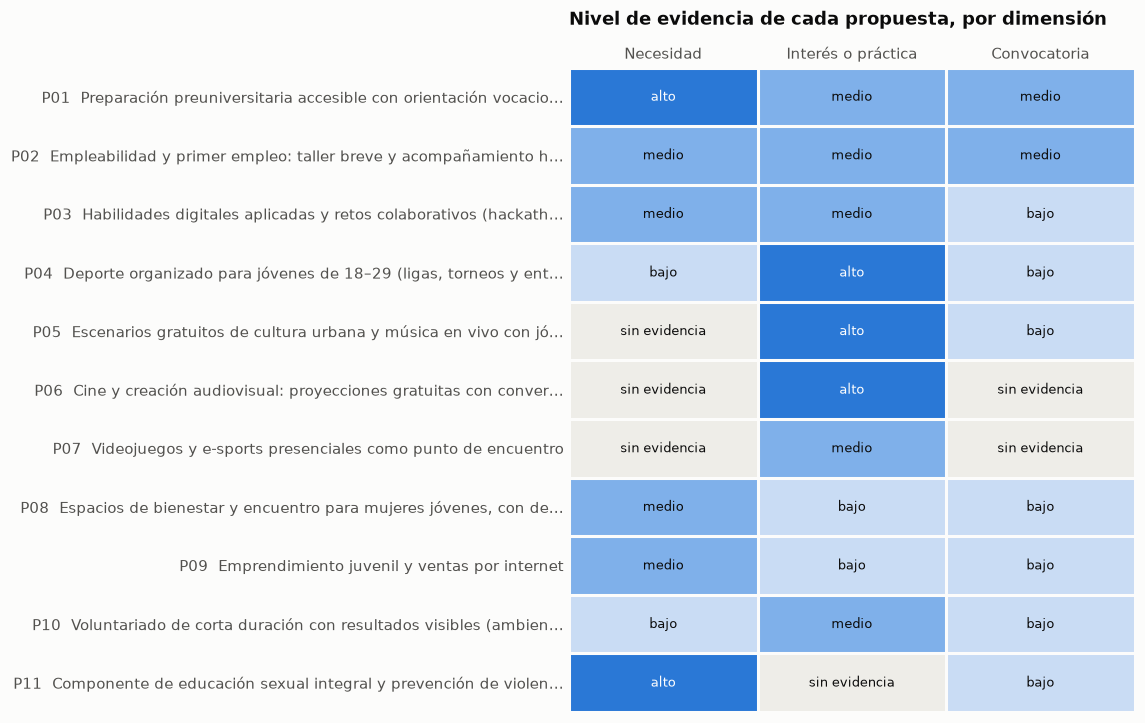

In [5]:
NIVELES = ["sin evidencia", "bajo", "medio", "alto"]
dims = {"nivel_necesidad": "Necesidad", "nivel_interes": "Interés o práctica", "nivel_convocatoria": "Convocatoria"}
m = prop.set_index("id")[list(dims)].apply(lambda s: s.map(NIVELES.index))
etiquetas = [f"{i}  {t[:62]}{'…' if len(t) > 62 else ''}" for i, t in zip(prop.id, prop.propuesta)]
fig, ax = plt.subplots(figsize=(10.5, 0.46 * len(m) + 1.6))
cmap = ListedColormap(["#eeede8", "#c9dcf4", "#7fb0ea", AZUL])
ax.imshow(m.values, cmap=cmap, vmin=0, vmax=3, aspect="auto")
for (i, j), v in np.ndenumerate(m.values):
    ax.text(j, i, NIVELES[v], ha="center", va="center", fontsize=8.5, color="white" if v == 3 else TINTA)
ax.set_xticks(range(3), list(dims.values())); ax.xaxis.tick_top()
ax.set_yticks(range(len(m)), etiquetas)
ax.set_xticks(np.arange(-.5, 3), minor=True); ax.set_yticks(np.arange(-.5, len(m)), minor=True)
ax.grid(which="minor", color=FONDO, linewidth=2)
ax.tick_params(which="both", length=0); [s.set_visible(False) for s in ax.spines.values()]
ax.set_title("Nivel de evidencia de cada propuesta, por dimensión", pad=28)
plt.tight_layout(); plt.show()

### 4.1 Lectura

- **Ninguna propuesta tiene evidencia alta de convocatoria.** La única demanda observada local para jóvenes es por
  una beca concreta, que no se generaliza.
- Las propuestas con **más respaldo en conjunto** son la **preparación preuniversitaria con orientación y becas
  (P01)** y la **empleabilidad y primer empleo (P02)**: tienen necesidad documentada y participación declarada con
  cifras en actividades similares en Lima Este.
- **Deporte para 18–29 (P04), cultura urbana y música en vivo (P05) y cine (P06)** tienen **práctica
  alta** medida en Lima Este, pero casi ninguna evidencia local de convocatoria: son las mejores candidatas para
  **pilotos que midan la convocatoria**.
- **Videojuegos (P07), emprendimiento (P09) y bienestar para mujeres jóvenes (P08)** descansan sobre todo en
  hipótesis; conviene validarlos antes de invertir en ellos (P08 tiene necesidad documentada, pero no interés ni
  convocatoria).

In [6]:
cols = ["id", "propuesta", "segmento", "hallazgos_c1", "hallazgos_c2", "hallazgos_c3", "convocatoria", "hipotesis", "validacion", "donde"]
display(prop[cols])

,id,propuesta,segmento,hallazgos_c1,hallazgos_c2,hallazgos_c3,convocatoria,hipotesis,validacion,donde
0,P01,Preparación preuniversitaria accesible con orientación vocacional y acompañamiento para postular a becas,16–19 años (5.º de secundaria y egresados recientes) de hogares con restricciones económicas,H1-01; H1-05,H2-11; H2-12,H3-02; H3-04; H3-05; H3-06,Hay participación declarada con cifras en actividades similares para el mismo segmento en Lima Este. La única demand...,Que una oferta adicional atraiga a jóvenes que hoy no acceden a ninguna preparación (y no desplace a las academias m...,Inscritos frente a cupos y lista de espera; asistencia sostenida (4.ª semana); proporción sin otra preparación; post...,"Criterio operativo, no de demanda: SJL concentra 99 mil adolescentes de 15–19 y no se encontró academia municipal gr..."
1,P02,Empleabilidad y primer empleo: taller breve y acompañamiento hacia vacantes reales,18–29 años que buscan trabajo o no estudian ni trabajan; prioridad mujeres jóvenes,H1-04; H1-06; H1-07,H2-06; H2-12; H2-14,H3-02; H3-07; H3-08; H3-09; H3-17,"Programas juveniles de empleabilidad en Lima Este con cifras pequeñas (62 aprobados, 50 y 143 jóvenes empleados). La...","Que jóvenes que no estudian, y en particular mujeres, acudan a un taller (el voluntariado casi no llega a quienes tr...",Inscritos frente a cupos; proporción de mujeres y de jóvenes que no estudian ni trabajan; asistencia; postulaciones ...,"Criterio operativo: SJL (Agencia Local de Empleo y Centro de Empleo del MTPE) y Santa Anita (nuevo Centro de Empleo,..."
2,P03,"Habilidades digitales aplicadas y retos colaborativos (hackathons, proyectos)",15–24 años (estudiantes de secundaria y superior) y 18–29 que buscan empleo,H1-09,H2-01; H2-08; H2-11,H3-02; H3-10; H3-17,"Un solo dato: la hackathon municipal de SJL tuvo más de 400 inscripciones (mayores de 18, de varios distritos, no so...","Qué contenidos convocan (ofimática para el empleo, diseño y contenido, programación); si el formato de reto convoca ...",Inscritos frente a cupos por contenido; asistencia; proyectos terminados; proporción de mujeres.,"Criterio operativo: SJL (experiencia previa de hackathon, coworking) y La Molina (CETPRO, computación gratuita para ..."
3,P04,"Deporte organizado para jóvenes de 18–29 (ligas, torneos y entrenamiento), con opciones seguras para mujeres jóvenes",18–29 años; submeta mujeres jóvenes,H1-02; H1-10,H2-02; H2-06; H2-15,H3-03; H3-11; H3-12; H3-17; H3-20,Para 18–29 casi no hay datos: un taller de tiro con arco (30 alumnos por horario) y carreras abiertas a todas las ed...,Que jóvenes de 18–29 se inscriban en deporte organizado si el horario es compatible; que un formato femenino o en ho...,"Inscritos por sexo y edad; asistencia y retención; comparación de horarios y formatos (femenino, mixto).","Criterio operativo: espacios nuevos o reabiertos en SJL (complejos del IPD, Club Wiracocha), Ate (Club Huaycán, Cahu..."
4,P05,Escenarios gratuitos de cultura urbana y música en vivo con jóvenes como artistas y organizadores,15–24 años,H1-02; H1-10,H2-03; H2-07; H2-09; H2-10,H3-04; H3-13,"Existen eventos de cultura urbana en Chosica, Santa Anita y SJL, pero ninguna nota informa asistencia juvenil; un fe...",Que un evento local y gratuito convoque a jóvenes (y no solo a familias); qué géneros; que participar como artista u...,Asistentes y rango de edad (registro o conteo); artistas y colectivos inscritos; asistencia a una segunda fecha.,"Criterio operativo: distritos con eventos previos y espacios (Chosica, Santa Anita, SJL); aliarse con organizaciones..."
5,P06,Cine y creación audiovisual: proyecciones gratuitas con conversación y taller de video para redes,15–24 años,H1-09,H2-07; H2-08; H2-09; H2-15,H3-13; H3-15,No hay actividad juvenil similar con datos en Lima Este: 'Cine en tu Barrio' se dirige a familias y no informa asist...,Que la práctica individual de ver cine y video se traduzca en asistencia a una actividad grupal; que haya interés en...,Asistentes po

## 5. Siguiente paso

Las propuestas son **hipótesis de convocatoria**. El paso siguiente es una consulta breve a jóvenes de Lima Este y
pilotos pequeños con indicadores definidos de antemano (inscritos frente a cupos, asistencia a la primera y cuarta
sesión, perfil de quienes llegan y canal por el que se enteraron). Ver `fuentes/metodologia_integracion.md` §5.